# Introduction to Exploratory Data Analysis
---

**Copyright and License**

© 2026, Fiorella Piriz Sapio

This Jupyter Notebook is licensed under the [MIT License](https://opensource.org/licenses/MIT).

**Disclaimer:**  
This notebook is provided "as is", without warranty of any kind, express or implied.  
The author assumes no responsibility or liability for any errors, omissions, or outcomes resulting from the use of this notebook or its contents.  
All analyses and interpretations are for educational and research purposes only and do not constitute medical or clinical advice.

**Dataset Note:**  
This notebook uses a publicly available synthetic pet supplies purchases dataset.

## Abstract: Introduction to Pandas

[Pandas](https://pandas.pydata.org/) is the go-to Python library for data manipulation and analysis. Built on top of NumPy, it introduces two core data structures — `Series` and `DataFrame` — that make working with structured, tabular data intuitive and expressive.

Pandas bridges the gap between raw data and meaningful analysis, offering tools to load, clean, transform, and explore datasets with minimal code.

### Why Pandas?
- **Tabular data:** DataFrames represent data in rows and columns, similar to a spreadsheet or SQL table.
- **Flexible I/O:** Read and write CSV, Excel, JSON, SQL, and more with a single function call.
- **Powerful indexing:** Label-based (`.loc`) and position-based (`.iloc`) access for precise data selection.
- **Ecosystem:** Pandas integrates seamlessly with NumPy, Matplotlib, and scikit-learn.

### Learning Objectives
By completing this notebook, students will be able to:
- Create and understand `Series` and `DataFrame` objects
- Access data using column labels, `.iloc`, and `.loc`
- Filter rows using boolean indexing
- Sort data with `.sort_values()`
- Perform basic aggregations: sum, mean
- Add new columns derived from existing data
- Import data from a local CSV file and from a URL
- Export a DataFrame to a CSV file
- Perform a first-look inspection of a real dataset
- Handle missing values and normalize string columns
- Group and aggregate data with `.groupby()`

### Real-World Context
Pandas is used across virtually every data-driven domain:
- **Data Science & ML:** Data cleaning, feature engineering, and exploratory analysis before model training.
- **Finance:** Time series analysis, portfolio tracking, and financial reporting.
- **Business Analytics:** Sales dashboards, KPI tracking, and cohort analysis.
- **Research:** Survey data processing, experimental results, and statistical summaries.

## 3. Data Source & Ethical Considerations

The dataset used is a synthetic pet supplies purchases dataset (`pet_supplies_2212.csv`).

- **Privacy:** No PII (Personally Identifiable Information) is included in the dataset.
- **Ethics:** Data is used solely for educational purposes to demonstrate pandas capabilities.

## 4. Setup & Library Imports

This section imports the libraries needed for this notebook.

In [1]:
# import pandas
import pandas as pd
import matplotlib.pyplot as plt

## Series

A `Series` is a one-dimensional labeled array — think of it as a single column of data with an index. It can hold any data type: integers, strings, floats, etc.

| Concept | Description |
|---------|-------------|
| `pd.Series(list)` | Create a Series from a Python list |
| `.values` | Underlying NumPy array |
| `.index` | Index labels |
| `.dtype` | Data type of elements |

In [2]:
# create series
snacks = pd.Series(["Granola Bar", "Banana", "Peanut Butter"])
costs  = pd.Series([3, 1, 5])

## DataFrame

A `DataFrame` is a two-dimensional labeled data structure — essentially a table with rows and columns. Each column is a `Series`.

| Concept | Description |
|---------|-------------|
| `pd.DataFrame(dict)` | Create from a dictionary of Series or lists |
| `.shape` | Tuple of (rows, columns) |
| `.dtypes` | Data type of each column |
| `.head(n)` | First n rows (default 5) |
| `.info()` | Summary of columns and non-null counts |

In [3]:
# combine Series into a DataFrame
snack_data = pd.DataFrame({"Snack": snacks, "Cost": costs})
print("Snack DataFrame:\n", snack_data)

Snack DataFrame:
            Snack  Cost
0    Granola Bar     3
1         Banana     1
2  Peanut Butter     5


## Accessing Data and Basic Operations

Pandas provides multiple ways to access data within a DataFrame:

| Method | Description |
|--------|-------------|
| `df["col"]` | Select a column by label |
| `df.iloc[n]` | Select a row by integer position |
| `df.loc[label]` | Select a row (or slice) by index label |
| `.sum()` | Sum of a column |
| `.mean()` | Mean of a column |
| `df["new"] = expr` | Add a new column |

In [4]:
# accessing data and basic operations
print("Access 'Snack' column:\n", snack_data["Snack"])        # access column
print("\nFirst row (iloc):\n", snack_data.iloc[0])            # access row by position
print("\nFirst row (loc):\n", snack_data.loc[0])              # access row by label
print("\nRows 0-1 (loc slice):\n", snack_data.loc[0:1])       # label-based slice
print("\nTotal cost of snacks:", snack_data["Cost"].sum())    # sum of column
print("Average snack cost:", snack_data["Cost"].mean())       # mean of column

Access 'Snack' column:
 0      Granola Bar
1           Banana
2    Peanut Butter
Name: Snack, dtype: str

First row (iloc):
 Snack    Granola Bar
Cost               3
Name: 0, dtype: object

First row (loc):
 Snack    Granola Bar
Cost               3
Name: 0, dtype: object

Rows 0-1 (loc slice):
          Snack  Cost
0  Granola Bar     3
1       Banana     1

Total cost of snacks: 9
Average snack cost: 3.0


In [5]:
# add new column
snack_data["Expensive"] = snack_data["Cost"] > 2
print("Updated Snack DataFrame:\n", snack_data)

Updated Snack DataFrame:
            Snack  Cost  Expensive
0    Granola Bar     3       True
1         Banana     1      False
2  Peanut Butter     5       True


## Boolean Filtering

Boolean filtering lets you select rows that match a condition — one of the most common pandas operations.

| Pattern | Description |
|---------|-------------|
| `df[df["col"] > x]` | Rows where column value exceeds x |
| `df[df["col"] == "val"]` | Rows matching a string value |
| `(cond1) & (cond2)` | AND — both conditions must be true |
| `(cond1) \| (cond2)` | OR — either condition must be true |

In [6]:
# filter expensive snacks
print("Snacks costing more than 2:\n", snack_data[snack_data["Cost"] > 2])

Snacks costing more than 2:
            Snack  Cost  Expensive
0    Granola Bar     3       True
2  Peanut Butter     5       True


In [7]:
# multiple conditions
print("Expensive snacks (cost > 2 AND expensive flag):\n",
      snack_data[(snack_data["Cost"] > 2) & (snack_data["Expensive"] == True)])

Expensive snacks (cost > 2 AND expensive flag):
            Snack  Cost  Expensive
0    Granola Bar     3       True
2  Peanut Butter     5       True


## Sorting

`.sort_values()` sorts a DataFrame by one or more columns.

| Parameter | Description |
|-----------|-------------|
| `by` | Column name (or list of names) to sort by |
| `ascending` | `True` (default) for ascending, `False` for descending |
| `ignore_index` | Reset index after sorting |

In [8]:
# sort by cost ascending
print("Sorted by cost (asc):\n", snack_data.sort_values(by="Cost"))

Sorted by cost (asc):
            Snack  Cost  Expensive
1         Banana     1      False
0    Granola Bar     3       True
2  Peanut Butter     5       True


In [9]:
# sort by cost descending
print("Sorted by cost (desc):\n", snack_data.sort_values(by="Cost", ascending=False))

Sorted by cost (desc):
            Snack  Cost  Expensive
2  Peanut Butter     5       True
0    Granola Bar     3       True
1         Banana     1      False


## Importing and Exporting Data

Pandas makes it easy to load data from many sources and save results back to disk.

| Function | Description |
|----------|-------------|
| `pd.read_csv(path)` | Load a CSV from a local path or URL |
| `df.head(n)` | Preview the first n rows |
| `df.to_csv(path, index=False)` | Export to CSV without the row index |

In [10]:
# import data from a local CSV
#df = pd.read_csv("../data/pet_supplies_2212.csv")

# import directly from GitHub (raw link)
df = pd.read_csv("https://raw.githubusercontent.com/abir9820/Exploratory_Analysis_of_Pet_Supplies_Purchases/master/Data%20Source/pet_supplies_2212.csv")
print("First 5 rows:\n", df.head())

First 5 rows:
    product_id  category animal    size  price    sales  rating  \
0           1      Food   Bird   large   51.1  1860.62     7.0   
1           2   Housing   Bird  MEDIUM  35.98   963.60     6.0   
2           3      Food    Dog  medium  31.23   898.30     5.0   
3           4  Medicine    Cat   small  24.95   982.15     6.0   
4           5   Housing    Cat   Small  26.18   832.63     7.0   

   repeat_purchase  
0                1  
1                0  
2                1  
3                1  
4                1  


In [11]:
# export data to CSV
import os
os.makedirs("../data", exist_ok=True)
df.to_csv("../data/pet_supplies_2212.csv", index=False)

## First Look at the Data

Before any analysis, always inspect the dataset to understand its structure, types, and quality.

| Method | Description |
|--------|-------------|
| `.shape` | Number of rows and columns |
| `.dtypes` | Data type of each column |
| `.info()` | Column names, non-null counts, dtypes |
| `.describe()` | Summary statistics for numeric columns |
| `.isnull().sum()` | Count of missing values per column |
| `.value_counts()` | Frequency of unique values in a column |

In [12]:
# shape and column types
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)

Shape: (1500, 8)

Data types:
 product_id           int64
category               str
animal                 str
size                   str
price                  str
sales              float64
rating             float64
repeat_purchase      int64
dtype: object


In [13]:
# full summary: non-null counts, dtypes, memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product_id       1500 non-null   int64  
 1   category         1500 non-null   str    
 2   animal           1500 non-null   str    
 3   size             1500 non-null   str    
 4   price            1500 non-null   str    
 5   sales            1500 non-null   float64
 6   rating           1350 non-null   float64
 7   repeat_purchase  1500 non-null   int64  
dtypes: float64(2), int64(2), str(4)
memory usage: 93.9 KB


In [14]:
# summary statistics for numeric columns
df.describe()

,product_id,sales,rating,repeat_purchase
count,1500.000000,1500.000000,1350.000000,1500.000000
mean,750.500000,996.597847,4.991111,0.604000
std,433.157015,323.952676,1.559755,0.489228
min,1.000000,286.940000,1.000000,0.000000
25%,375.750000,747.420000,4.000000,0.000000
50%,750.500000,1000.830000,5.000000,1.000000
75%,1125.250000,1158.157500,6.000000,1.000000
max,1500.000000,2255.960000,9.000000,1.000000


In [15]:
# missing values per column
print("Missing values:\n", df.isnull().sum())

Missing values:
 product_id           0
category             0
animal               0
size                 0
price                0
sales                0
rating             150
repeat_purchase      0
dtype: int64


In [16]:
# unique value counts for categorical columns
for col in ["category", "animal", "size"]:
    print(f"\n{col}:\n", df[col].value_counts())


category:
 category
Equipment    370
Food         260
Toys         255
Medicine     237
Housing      227
Accessory    126
-             25
Name: count, dtype: int64

animal:
 animal
Cat     567
Fish    369
Dog     367
Bird    197
Name: count, dtype: int64

size:
 size
small     372
medium    233
Small     225
SMALL     157
Medium    150
large     122
MEDIUM    109
Large      75
LARGE      57
Name: count, dtype: int64


## Handling Missing Values

Real datasets are rarely clean. Pandas provides tools to detect, remove, or fill missing values.

| Method | Description |
|--------|-------------|
| `.isnull()` | Boolean mask — True where value is NaN |
| `.dropna()` | Remove rows (or columns) with any NaN |
| `.fillna(value)` | Replace NaN with a given value |

> In this dataset, `price` contains `"unlisted"` strings and `rating` contains `"NA"` strings — these are not true NaN yet. We need to convert them first.

In [17]:
# replace non-numeric placeholders with actual NaN
df["price"]  = pd.to_numeric(df["price"],  errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
print("Missing values after conversion:\n", df.isnull().sum())

Missing values after conversion:
 product_id           0
category             0
animal               0
size                 0
price              150
sales                0
rating             150
repeat_purchase      0
dtype: int64


In [18]:
# fill missing price with the median price
df["price"] = df["price"].fillna(df["price"].median())

# fill missing rating with the median rating
df["rating"] = df["rating"].fillna(df["rating"].median())

print("Missing values after fill:\n", df.isnull().sum())

Missing values after fill:
 product_id         0
category           0
animal             0
size               0
price              0
sales              0
rating             0
repeat_purchase    0
dtype: int64


## String Normalization

Categorical columns often have inconsistent casing (`Small`, `SMALL`, `small`). The `.str` accessor lets you apply string operations across an entire column.

| Method | Description |
|--------|-------------|
| `.str.lower()` | Convert to lowercase |
| `.str.strip()` | Remove leading/trailing whitespace |
| `.str.replace(old, new)` | Replace substrings |
| `.str.title()` | Title case |

In [19]:
# before normalization
print("size unique values before:\n", df["size"].unique())

size unique values before:
 <StringArray>
[ 'large', 'MEDIUM', 'medium',  'small',  'Small',  'Large',  'SMALL',
 'Medium',  'LARGE']
Length: 9, dtype: str


In [20]:
# normalize size and category to lowercase, strip whitespace
df["size"]     = df["size"].str.strip().str.lower()
df["category"] = df["category"].str.strip().str.lower()
df["animal"]   = df["animal"].str.strip().str.lower()

print("size unique values after:\n", df["size"].unique())

size unique values after:
 <StringArray>
['large', 'medium', 'small']
Length: 3, dtype: str


## GroupBy and Aggregation

`.groupby()` splits the DataFrame into groups and applies an aggregation function to each group — similar to SQL `GROUP BY`.

| Pattern | Description |
|---------|-------------|
| `df.groupby("col")["val"].mean()` | Mean of `val` per group |
| `df.groupby("col")["val"].sum()` | Sum of `val` per group |
| `df.groupby("col").agg({...})` | Multiple aggregations at once |

In [21]:
# average sales per category
print("Avg sales per category:\n",
      df.groupby("category")["sales"].mean().sort_values(ascending=False))

Avg sales per category:
 category
toys         1254.498431
-            1132.650800
food         1104.377538
accessory     962.487619
equipment     942.906054
medicine      903.233122
housing       772.380220
Name: sales, dtype: float64


In [22]:
# average sales per animal
print("Avg sales per animal:\n",
      df.groupby("animal")["sales"].mean().sort_values(ascending=False))

Avg sales per animal:
 animal
bird    1395.939036
dog     1058.326294
cat     1012.755079
fish     697.178591
Name: sales, dtype: float64


In [23]:
# multiple aggregations: mean price and total sales per category
df.groupby("category").agg(
    avg_price=("price", "mean"),
    total_sales=("sales", "sum"),
    product_count=("product_id", "count")
).sort_values("total_sales", ascending=False)

,avg_price,total_sales,product_count
category,,,
equipment,26.960351,348875.24,370
toys,33.263020,319897.10,255
food,33.687615,287138.16,260
medicine,25.069705,214066.25,237
housing,26.516564,175330.31,227
accessory,31.345079,121273.44,126
-,32.244800,28316.27,25


## Quick Plots

A few simple plots to visually inspect distributions and category breakdowns — just enough to know what we're working with before deeper analysis.

> `df[col].value_counts().plot(kind='bar')` is the quickest way to visualise a categorical column.

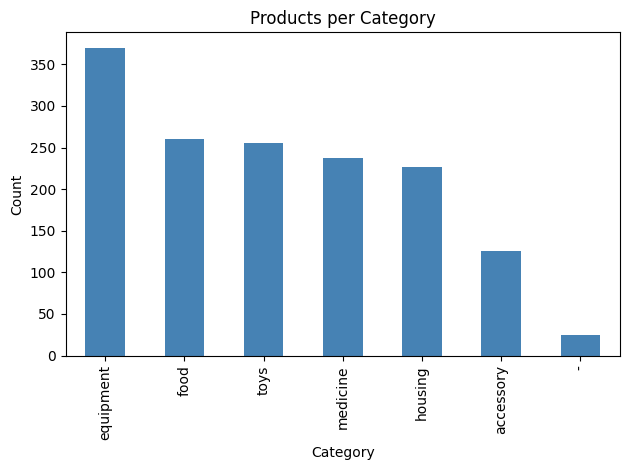

In [24]:
# products per category
df["category"].value_counts().plot(kind="bar", title="Products per Category", color="steelblue")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

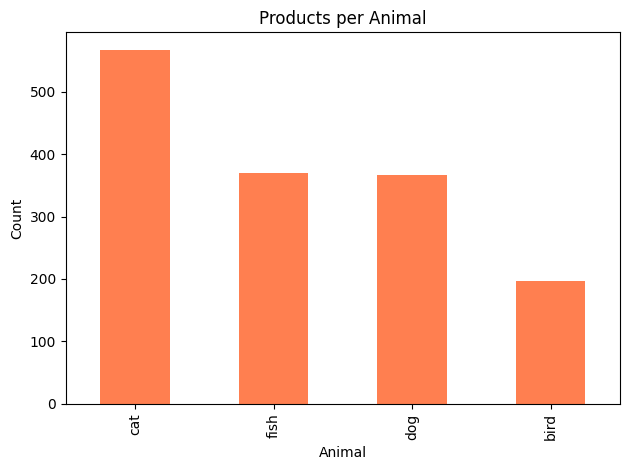

In [25]:
# products per animal type
df["animal"].value_counts().plot(kind="bar", title="Products per Animal", color="coral")
plt.xlabel("Animal")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

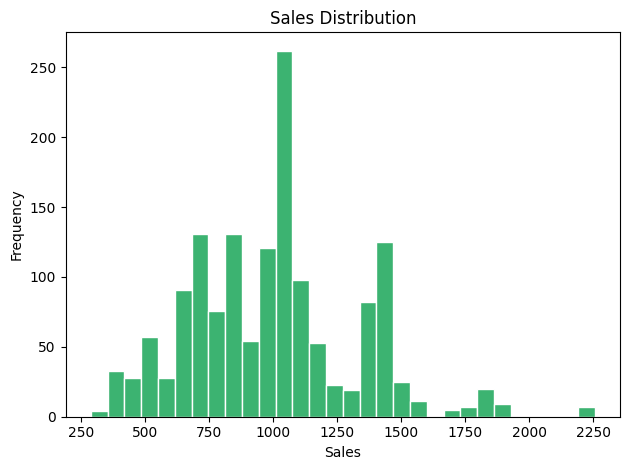

In [26]:
# sales distribution
df["sales"].plot(kind="hist", bins=30, title="Sales Distribution", color="mediumseagreen", edgecolor="white")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

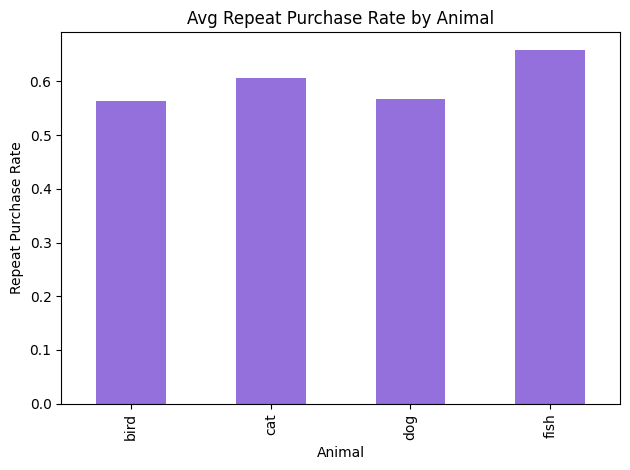

In [27]:
# average repeat purchase rate by animal
df.groupby("animal")["repeat_purchase"].mean().plot(kind="bar", title="Avg Repeat Purchase Rate by Animal", color="mediumpurple")
plt.xlabel("Animal")
plt.ylabel("Repeat Purchase Rate")
plt.tight_layout()
plt.show()

## Challenge

Put your pandas skills to the test using the pet supplies dataset. Complete the following tasks **without looking at previous cells**.

1. Print the shape of `df`.
2. Select only rows where `animal` is `"dog"`.
3. Use `.loc` to retrieve rows 10 through 15.
4. Sort the DataFrame by `sales` descending and show the top 5.
5. Add a column `"high_sales"` that is `True` when `sales > 1000`.
6. Count how many products have high sales using `.sum()`.
7. Group by `category` and compute the average `rating` per category.
8. Plot a bar chart of average sales per `size`.

In [28]:
# 1. Shape

# 2. Filter dog products

# 3. loc rows 10-15

# 4. Top 5 by sales

# 5. Add 'high_sales' column

# 6. Count high sales products

# 7. Avg rating per category

# 8. Bar chart: avg sales per size
